In [1]:
import uproot
import dask_awkward as dak
import awkward as ak
import zfit
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import mplhep as hep
from dask.diagnostics import ProgressBar

/cvmfs/sft.cern.ch/lcg/views/LCG_109_cuda/x86_64-el9-gcc13-opt/lib/python3.13/site-packages/zfit/__init__.py:93: UserWarning: TensorFlow warnings are by default suppressed by zfit. In order to show them, set the environment variable ZFIT_DISABLE_TF_WARNINGS=0. In order to suppress the TensorFlow warnings AND this warning, set ZFIT_DISABLE_TF_WARNINGS=1.
  warnings.warn(


In [2]:
plt.style.use(hep.style.CMS)

In [3]:
mc_files = {"/eos/user/t/tdeandra/skim_outputs/Merged_Eras/Merged_mc_signal_2022.root": "Events"}
df = uproot.dask(mc_files)

In [4]:
def get_perfect_b0_matter_mask(df):
    # --- 1. Constantes PDG ---
    PDG_B0        = 511
    PDG_KSTAR     = 313
    PDG_KAON_plus = 321
    PDG_PION_neg  = -211
    PDG_MUON_plus = -13
    PDG_MUON_neg  = 13
    PDG_PHOTON    = 22

    mu1_idx  = df["BPH_1Muon_genPartIdx"]
    mu2_idx  = df["BPH_2Muon_genPartIdx"]
    trk1_idx = df["Trk1_genPartIdx"]
    trk2_idx = df["Trk2_genPartIdx"]

    # Verificação de Identidade (PDG ID)
    mu1_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mu2_pdg  = df["BPHGenPart_pdgId"][dak.mask(mu2_idx, mu2_idx >= 0)]
    trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(trk1_idx, trk1_idx >= 0)]
    trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(trk2_idx, trk2_idx >= 0)]

    flavor_match = (trk1_pdg == PDG_KAON_plus) & (trk2_pdg == PDG_PION_neg) & \
                   (mu1_pdg == PDG_MUON_plus) & (mu2_pdg == PDG_MUON_neg)

    # Linhagem do Hadron (K, Pi -> K* -> B0)
    mom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk1_idx, trk1_idx >= 0)]
    mom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(trk2_idx, trk2_idx >= 0)]
    
    mom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    mom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    # K e Pi devem vir do mesmo objeto K*0 
    match_kstar = (mom_trk1_idx == mom_trk2_idx) & (mom_trk1_idx >= 0) & \
                  (mom_trk1_pdg == PDG_KSTAR) & (mom_trk2_pdg == PDG_KSTAR)
    
    # O K*0 deve vir de um B0 (Verificando para ambos os traços)
    gmom_trk1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk1_idx, mom_trk1_idx >= 0)]
    gmom_trk2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_trk2_idx, mom_trk2_idx >= 0)]
    
    gmom_trk1_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk1_idx, gmom_trk1_idx >= 0)]
    gmom_trk2_pdg = df["BPHGenPart_pdgId"][dak.mask(gmom_trk2_idx, gmom_trk2_idx >= 0)]
    
    match_kstar_to_b0 = (gmom_trk1_idx == gmom_trk2_idx) & (gmom_trk1_idx >= 0) & \
                        (gmom_trk1_pdg == PDG_B0) & (gmom_trk2_pdg == PDG_B0)

    mom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu1_idx, mu1_idx >= 0)]
    mom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mu2_idx, mu2_idx >= 0)]
    mom_mu1_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    mom_mu2_pdg = df["BPHGenPart_pdgId"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]
    
    gmom_mu1_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu1_idx, mom_mu1_idx >= 0)]
    gmom_mu2_idx = df["BPHGenPart_genPartIdxMother"][dak.mask(mom_mu2_idx, mom_mu2_idx >= 0)]

    # Muon 1: Mãe é o B0 do hadron OU (Mãe é fóton e Avô é o B0 do hadron)
    mu1_from_same_b0 = (mom_mu1_idx == gmom_trk1_idx) | \
                       ((mom_mu1_pdg == PDG_PHOTON) & (gmom_mu1_idx == gmom_trk1_idx))

    mu2_from_same_b0 = (mom_mu2_idx == gmom_trk1_idx) | \
                       ((mom_mu2_pdg == PDG_PHOTON) & (gmom_mu2_idx == gmom_trk1_idx))

    # --- Máscara Final ---
    full_mask = flavor_match & match_kstar & match_kstar_to_b0 & \
                mu1_from_same_b0 & mu2_from_same_b0
    
    return ak.fill_none(full_mask, False)

In [15]:
def apply_selection(df):
    mask = (        
        # --- Veto de Ressonâncias (J/psi e psi(2S)) ---
        (((df['MuMu_mass'] > 1.0) & (df['MuMu_mass'] < 2.7)) | 
         ((df['MuMu_mass'] > 4.0) & (df['MuMu_mass'] < 6.0))) & 
        
        # --- Seleção do K*0 (892) ---
        (abs(df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] - 0.892) <= 0.150) & 
        (abs(df['BToTrkTrkMuMu_fit_ditrack_mass_piK'] - 0.892) <= 0.150) & 
        (df['BToTrkTrkMuMu_fit_ditrack_mass_Kpi'] < df['BToTrkTrkMuMu_fit_ditrack_mass_piK']) & 
        
        # --- Aceitação dos Múons ---
        (df['BPH_1Muon_pt'] > 2.0) & (df['BPH_2Muon_pt'] > 2.0) & 
        (abs(df['BPH_1Muon_eta']) < 2.5) & (abs(df['BPH_2Muon_eta']) < 2.5) &
        (df['BToTrkTrkMuMu_fit_trk1_pt'] > 1.5) &
        (df['BToTrkTrkMuMu_fit_trk2_pt'] > 1.5) 
    )
    
    return ak.fill_none(mask, False)

In [16]:
with ProgressBar():
    rare_mask = get_perfect_b0_matter_mask(df)
    kin_mask = apply_selection(df)
    final_mask = rare_mask & kin_mask
    clean_mass = df["BToTrkTrkMuMu_fit_mass_Kpi"][final_mask]

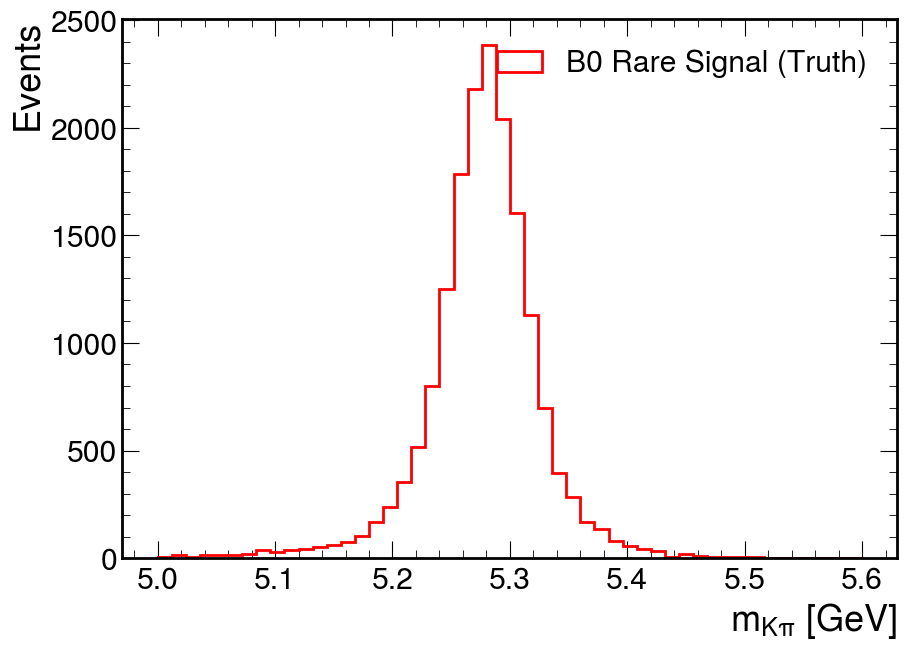

In [17]:
plt.figure(figsize=(10, 7))
data = ak.to_numpy(ak.flatten(clean_mass.compute(), axis=None))
plt.hist(data, bins=50, histtype='step',range=(5.0, 5.6), lw=2, color='red', label='B0 Rare Signal (Truth)')
plt.xlabel(r"$m_{K\pi}$ [GeV]")
plt.ylabel("Events")
plt.legend()
plt.show()

In [18]:
mass_min, mass_max = 5.0, 5.6
obs = zfit.Space("m_b", limits=(mass_min, mass_max))

In [19]:
mu    = zfit.Parameter("mu", 5.279, 5.2, 5.4)
sigma = zfit.Parameter("sigma", 0.02, 0.001, 0.1)
alphal = zfit.Parameter("alphal", 1.5, 0.1, 5.0)
nl     = zfit.Parameter("nl", 2.0, 0.1, 30.0)
alphar = zfit.Parameter("alphar", 1.5, 0.1, 5.0)
nr     = zfit.Parameter("nr", 2.0, 0.1, 30.0)

In [20]:
model = zfit.pdf.DoubleCB(obs=obs, mu=mu, sigma=sigma, 
                          alphal=alphal, nl=nl, alphar=alphar, nr=nr
                          )

In [21]:
zfit_data = zfit.Data.from_numpy(obs=obs, array=data)
nll = zfit.loss.UnbinnedNLL(model=model, data=zfit_data)
minimizer = zfit.minimize.Minuit()
result = minimizer.minimize(nll)

In [22]:
result.errors()
print(f"Fit Convergiu? {result.converged}")
print(result)

Fit Convergiu? True
FitResult of
<UnbinnedNLL model=[<zfit.<class 'zfit.models.physics.DoubleCB'>  params=[alphal, alphar, mu, nl, nr, sigma]] data=[<zfit.Data: Data obs=('m_b',) shape=(16931, 1)>] constraints=[]> 
with
<Minuit Minuit, tol=0.001>

╒═════════╤═════════════╤══════════════════╤═════════╤══════════════════════════════╕
│  valid  │  converged  │  param at limit  │   edm   │   approx. fmin (full | opt.) │
╞═════════╪═════════════╪══════════════════╪═════════╪══════════════════════════════╡
│  True   │    True     │      False       │ 2.7e-06 │        -28835.46 |  8740.245 │
╘═════════╧═════════════╧══════════════════╧═════════╧══════════════════════════════╛

Parameters
name      value  (rounded)               errors    at limit
------  ------------------  -------------------  ----------
mu                 5.28013  -0.00036   +0.00036       False
sigma            0.0309902  - 0.0005   +0.00047       False
alphal             1.32132  -  0.049   +  0.049       False
nl        

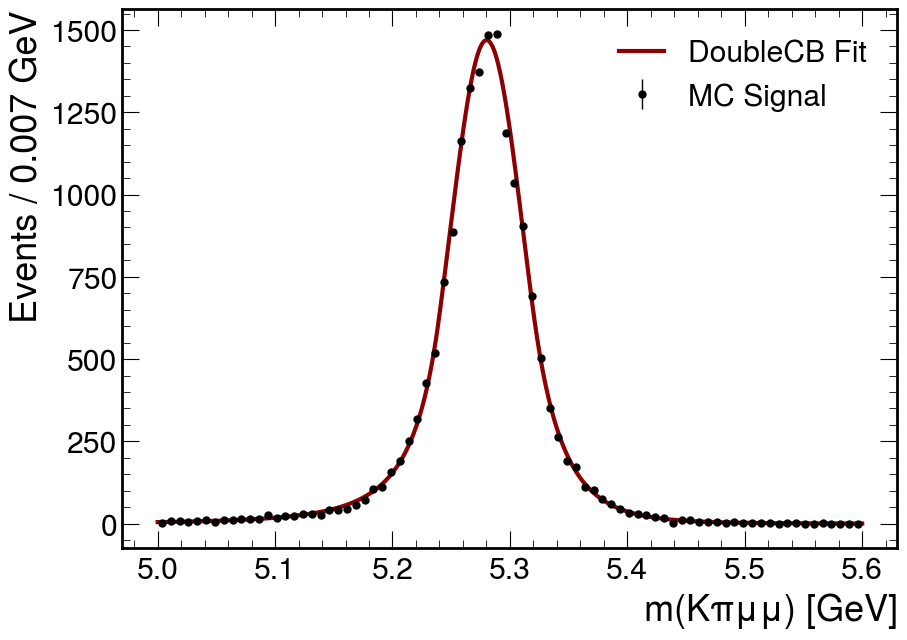

In [23]:
plt.figure(figsize=(10, 7))
num_bins = 80
counts, bin_edges = np.histogram(data, bins=num_bins, range=(mass_min, mass_max))
bin_width = (mass_max - mass_min) / num_bins

x_plot = np.linspace(mass_min, mass_max, 1000)
y_plot = model.pdf(x_plot).numpy() * len(data) * bin_width

hep.histplot(counts, bins=bin_edges, color='black', label='MC Signal', histtype='errorbar')
plt.plot(x_plot, y_plot, color='darkred', lw=3, label='DoubleCB Fit')

plt.xlabel(r"$m(K\pi\mu\mu)$ [GeV]")
plt.ylabel(f"Events / {bin_width:.3f} GeV")
plt.legend()
plt.show()

In [24]:
cov_matrix = result.covariance()
print("Matriz de Covariância:")
print(cov_matrix)

Matriz de Covariância:
[[ 1.29390217e-07  2.09896208e-09 -4.99266037e-06  3.14961680e-05
   6.07135463e-06 -1.86240791e-04]
 [ 2.09896208e-09  2.38538438e-07  1.44651669e-05 -5.40379898e-05
   1.74949671e-05 -2.95691547e-04]
 [-4.99266037e-06  1.44651669e-05  2.33946236e-03 -1.48549821e-02
   9.31249432e-04 -1.36007859e-02]
 [ 3.14961680e-05 -5.40379898e-05 -1.48549821e-02  1.26917883e-01
  -3.01439752e-03  3.60331385e-02]
 [ 6.07135463e-06  1.74949671e-05  9.31249432e-04 -3.01439752e-03
   2.92969688e-03 -8.87177535e-02]
 [-1.86240791e-04 -2.95691547e-04 -1.36007859e-02  3.60331385e-02
  -8.87177535e-02  3.91146971e+00]]


In [25]:
nll_value = result.fmin
print(f"Log-Likelihood mínimo: {nll_value:.2f}")

counts, bin_edges = np.histogram(data, bins=80, range=(5.0, 5.6))
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
bin_width = bin_edges[1] - bin_edges[0]

expected_counts = model.pdf(bin_centers).numpy() * len(data) * bin_width
mask = counts > 0
chi2 = np.sum(((counts[mask] - expected_counts[mask])**2) / expected_counts[mask])
n_params = len(result.params)
ndf = len(counts) - n_params

print(f"Chi2: {chi2:.2f}")
print(f"NDF: {ndf}")
print(f"Chi2/NDF: {chi2/ndf:.2f}")

Log-Likelihood mínimo: -28835.46
Chi2: 75.60
NDF: 74
Chi2/NDF: 1.02


In [26]:
edm = result.edm
print(f"EDM (Estimated Distance to Minimum): {edm:.6f}")

EDM (Estimated Distance to Minimum): 0.000003


In [27]:
res_raw = result.info['original']
fmin = res_raw.fmin if hasattr(res_raw, 'fmin') else res_raw

print(f"--- STATUS DO MINUIT (covQ) ---")
print(f"1. Fit Convergiu (Migrad):    {fmin.is_valid}")
print(f"2. Matriz de Covariância:     {fmin.has_covariance}")
print(f"3. Matriz é Precisa (covQ=3): {fmin.has_accurate_covar}")
print(f"4. EDM (Distância ao Mínimo): {fmin.edm:.6f}")

--- STATUS DO MINUIT (covQ) ---
1. Fit Convergiu (Migrad):    True
2. Matriz de Covariância:     True
3. Matriz é Precisa (covQ=3): True
4. EDM (Distância ao Mínimo): 0.000002


<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:37: SyntaxWarning: invalid escape sequence '\m'
<>:38: SyntaxWarning: invalid escape sequence '\s'
<>:39: SyntaxWarning: invalid escape sequence '\c'
<>:40: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_340/418673770.py:37: SyntaxWarning: invalid escape sequence '\m'
  plt.Line2D([0], [0], color='none', label=f"$\mu = {mu_val:.4f}$ GeV"),
/tmp/ipykernel_340/418673770.py:38: SyntaxWarning: invalid escape sequence '\s'
  plt.Line2D([0], [0], color='none', label=f"$\sigma = {sigma_val:.4f}$ GeV"),
/tmp/ipykernel_340/418673770.py:39: SyntaxWarning: invalid escape sequence '\c'
  plt.Line2D([0], [0], color='none', label=f"$\chi^2/\mathrm{{ndf}} = {(chi2/ndf):.2f}$"),
/tmp/ipykernel_340/418673770.py:40: SyntaxWarning: invalid escape sequence '\m'
  plt.Line2D([0], [0], color=

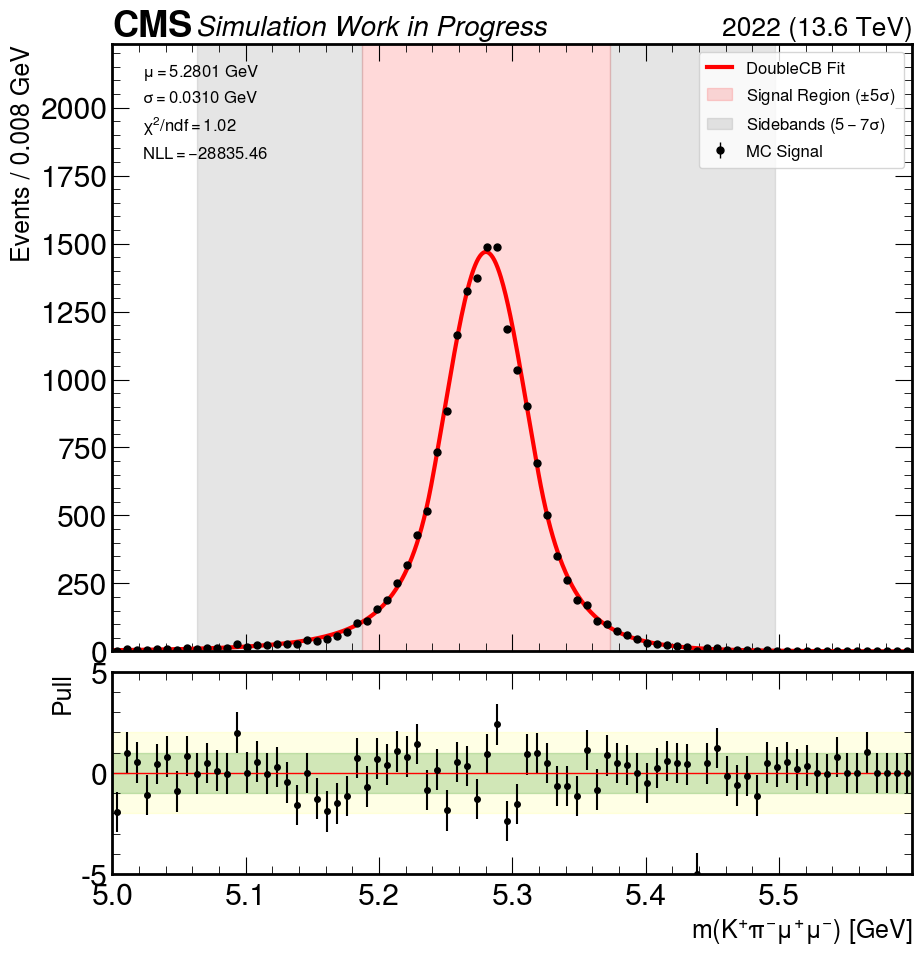

In [37]:
bin_range = (bin_edges[0], bin_edges[-1])

mu_val = model.params['mu'].numpy()
sigma_val = model.params['sigma'].numpy()
sig_low, sig_high = mu_val - 3*sigma_val, mu_val + 3*sigma_val
bg_neg_low, bg_neg_high = mu_val - 3*sigma_val, mu_val - 7*sigma_val
bg_pos_low, bg_pos_high = mu_val + 3*sigma_val, mu_val + 7*sigma_val

# ... (seu código de definição de mu_val, sigma_val, etc)

fig = plt.figure(figsize=(10, 10))
gs = gridspec.GridSpec(2, 1, height_ratios=[3, 1], hspace=0.05) 
ax1 = plt.subplot(gs[0])
ax2 = plt.subplot(gs[1])

# Plotagem principal
hep.histplot(counts, bins=bin_edges, ax=ax1, color='black', label='MC Signal', histtype='errorbar')
ax1.plot(x_plot, y_plot, color='red', lw=3, label='DoubleCB Fit')

# Regiões
ax1.axvspan(sig_low, sig_high, color='red', alpha=0.15, label=r'Signal Region ($\pm 5\sigma$)')
ax1.axvspan(bg_neg_low, bg_neg_high, color='gray', alpha=0.2, label=r'Sidebands ($5-7\sigma$)')
ax1.axvspan(bg_pos_low, bg_pos_high, color='gray', alpha=0.2)

# --- CONFIGURAÇÃO DAS LEGENDAS ---

# 1. Legenda da Direita (Labels dos plots)
# Pegamos os handles e labels atuais do eixo
handles, labels = ax1.get_legend_handles_labels()
leg_right = ax1.legend(handles, labels, loc='upper right', fontsize=12, frameon=True)
# Adicionamos manualmente para que a próxima legenda não a remova
ax1.add_artist(leg_right)

# 2. Legenda da Esquerda (Valores do Fit)
# Criamos handles "fantasmagóricos" (sem marcador) apenas para o texto
fit_info = [
    plt.Line2D([0], [0], color='none', label=f"$\mu = {mu_val:.4f}$ GeV"),
    plt.Line2D([0], [0], color='none', label=f"$\sigma = {sigma_val:.4f}$ GeV"),
    plt.Line2D([0], [0], color='none', label=f"$\chi^2/\mathrm{{ndf}} = {(chi2/ndf):.2f}$"),
    plt.Line2D([0], [0], color='none', label=f"$\mathrm{{NLL}} = {nll_value:.2f}$")
]
ax1.legend(handles=fit_info, loc='upper left', fontsize=12, frameon=False, handlelength=0)

# --- RESTO DO CÓDIGO ---

ax1.set_ylabel(f"Events / {bin_width:.3f} GeV", fontsize=18)
ax1.set_xlim(bin_edges[0], bin_edges[-1]) 
ax1.set_ylim(0, max(counts) * 1.5) 

hep.cms.label("Work in Progress", data=False, year="2022", ax=ax1, com=13.6, fontsize=20)
ax1.tick_params(axis='x', labelbottom=False)

# Pull plot
expected = model.pdf(bin_centers).numpy() * np.sum(counts) * bin_width
pulls = np.divide(counts - expected, np.sqrt(counts), out=np.zeros_like(counts, dtype=float), where=counts>0)

ax2.errorbar(bin_centers, pulls, yerr=1, fmt='o', color='black', markersize=4, capsize=0)
ax2.axhline(0, color='red', linestyle='-', lw=1)
ax2.fill_between([bin_edges[0], bin_edges[-1]], -1, 1, color='green', alpha=0.2)
ax2.fill_between([bin_edges[0], bin_edges[-1]], -2, 2, color='yellow', alpha=0.1)
ax2.set_xlabel(r"$m(K^{+}\pi^{-}\mu^{+}\mu^{-})$ [GeV]", fontsize=18)
ax2.set_ylabel("Pull", fontsize=18)
ax2.set_ylim(-5, 5)
ax2.set_xlim(bin_edges[0], bin_edges[-1])
ax2.grid(axis='y', linestyle=':', alpha=0.6)

plt.subplots_adjust(left=0.15, right=0.95, top=0.95, bottom=0.12)
plt.show()

In [33]:
n_params

6

In [ ]:
sigma_val, sig_low, sig_high